## PROBLEM STATEMENT
The dataset being used for the competition ‘New York City Taxi Trip Duration’ consist of the trip details
for about 1.4 million taxi rides between the years 2009 and 2015 in New York city.
The main aim of the challenge is to predict the duration of a taxi ride, which makes it a supervised regression problem to begin with. For this contest the evaluation metric is the Root Mean Squared Log Error.

## APPROACH 
My approach to the problem is multifold in nature, 
- The first step being exploratory data analysis (EDA) where I explore the data to get an insight of the features and inputs existing which will lead to some visualizations for more information. 

- Post the EDA comes the step of feature engineering, this is the step where I use the secondary datasets and transform the data present in all datasets to create a relevant featurespace for my model. This also involves transforming the features to make it compatible with the chosen model.

- Once the final feature space is obtained I will model a regressor (XGBoost here) to generate a score and a submission file for the competition. 

- This first draft will now undergo fine tuning and hyper-parameter tuning in order to further reduce the error and create my final submission file.

In [3]:
# importing the required libraries 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime # to tackle the date time features
from datetime import date
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns #pretty plots
import warnings
sns.set()



## EXPLORING THE DATA & FEATURE ENGINEERING

In [4]:
#reading the training and testing data and storing them as data and test respectively.
data =  pd.read_csv('D:\DataProject/New York Taxi/train.csv', parse_dates =['pickup_datetime'])
dates=['pickup_datetime']
test = pd.read_csv('D:\DataProject/New York Taxi/test.csv',parse_dates = ['pickup_datetime'])
data.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
# checking the types of columns and entries in the data and test.
data.info()
test.info()
#using the describe() function to get and idea about different features and their stats
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 122.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,2016-04-01 10:10:24.940037120,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
min,1.000000e+00,2016-01-01 00:00:17,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,2016-02-17 16:46:04.249999872,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,2016-04-01 17:19:40,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2016-05-15 03:56:08.750000128,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,2016-06-30 23:59:39,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06
std,4.987772e-01,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03


In [6]:
#getting individual components of date time
#converting store_and_fwd_flag to a 0 and 1 from a categorical data as only 2 possible values.
for df in (data,test):
    df['year'] = df['pickup_datetime'].dt.year
    df['month'] = df['pickup_datetime'].dt.month
    df['day'] = df['pickup_datetime'].dt.day
    df['hr'] = df['pickup_datetime'].dt.hour
    df['minute'] = df['pickup_datetime'].dt.minute
    #converting flag into 0 or 1
    df['store_and_fwd_flag'] = 1 * (df.store_and_fwd_flag.values== 'Y')

In [7]:

 
print(data[data['pickup_longitude']<-74.2].shape[0]) #points with longitude out of range, possible outliers
print((data['vendor_id']==2).mean())  #Distribution by vendor id
print((data['store_and_fwd_flag']==1).mean()) #distribution by store_and_fwd_flag
print(data[data['store_and_fwd_flag']==1].shape[0])


82
0.5349502688798637
0.005515396491535975
8045


In [8]:
#converting trip duration to log(trip_duration +1) for rmsle
data = data.assign(log_trip_duration = np.log(data.trip_duration+1)) 


#### Considering the impact of holidays 

In [9]:
#since ride duration will depend on holiday or workday etc importing nyc 2016 holiday dataset
holiday = pd.read_csv('../input/nyc2016holidays/NYC_2016Holidays.csv', sep = ';') # secondary dataset for restdays
holiday['Date'] = holiday['Date'].apply(lambda x: x+ '2016')
holidays = [datetime]

FileNotFoundError: [Errno 2] No such file or directory: '../input/nyc2016holidays/NYC_2016Holidays.csv'

In [9]:
#storing restday features into new data frames (will merge them later)
time_data = pd.DataFrame(index = range(len(data)))  
time_test = pd.DataFrame(index = range(len(test)))

In [10]:
# we will list out the weekends and rest days(holidays)
# will return if its a holiday or weekend

from datetime import date
def find_holiday(yr, month, day, holidays):
    holiday =  [None]*len(yr)
    weekend =  [None]*len(yr)
    i = 0 
    for yy,mm,dd in zip(yr, month, day):
        #checking for saturday sunday(6,7), date.isoweekday() returns the day
        weekend[i] = date(yy,mm,dd).isoweekday() in (6,7)
        holiday[i] = weekend[i] or date(yy,mm,dd)  in holidays
        i+=1
    return holiday, weekend
    

In [11]:
#for training data, creating rest_day and weekend columns in a new dataframe (will merge later)
rest_day,weekend = find_holiday(data.year, data.month, data.day, holidays)
time_data = time_data.assign(rest_day = rest_day)
time_data = time_data.assign(weekend = weekend)

#replicating for test data
rest_day,weekend = find_holiday(test.year, test.month, test.day, holidays)
time_test = time_test.assign(rest_day = rest_day)
time_test = time_test.assign(weekend = weekend)

In [12]:
#changing time into floats 
time_data = time_data.assign(pickup_time = data.hr+data.minute/60)
time_test = time_test.assign(pickup_time = test.hr+ test.minute/60)

#### Considering the impact of OSRM features

In [13]:
#using OSRM feature of fastroute (its split into 2 files)
fastrout1 = pd.read_csv('../input/new-york-city-taxi-with-osrm/fastest_routes_train_part_1.csv', usecols=['id','total_distance','total_travel_time','number_of_steps','step_direction'])
fastrout2 = pd.read_csv('../input/new-york-city-taxi-with-osrm/fastest_routes_train_part_2.csv', usecols=['id','total_distance','total_travel_time','number_of_steps','step_direction'])
#merging data from the 2 fastrout files
fastrout = pd.concat((fastrout1,fastrout2))
fastrout.head()

,id,total_distance,total_travel_time,number_of_steps,step_direction
0,id2875421,2009.1,164.9,5,left|straight|right|straight|arrive
1,id2377394,2513.2,332.0,6,none|right|left|right|left|arrive
2,id3504673,1779.4,235.8,4,left|left|right|arrive
3,id2181028,1614.9,140.1,5,right|left|right|left|arrive
4,id0801584,1393.5,189.4,5,right|right|right|left|arrive


In [14]:
#from the data calculating the number for strict lefts and rights
right_turn = []
left_turn = []
right_turn+= list(map(lambda x:x.count('right')-x.count('slight right'), fastrout.step_direction))
left_turn+= list(map(lambda x:x.count('left')-x.count('slight left'), fastrout.step_direction))

In [15]:
# storing the osrm features in a new dataframe (will merge later)
osrm_data = fastrout[['id', 'total_distance', 'total_travel_time','number_of_steps']]
osrm_data = osrm_data.assign(right_steps = right_turn)
osrm_data = osrm_data.assign(left_steps = left_turn)
osrm_data.head(3)

,id,total_distance,total_travel_time,number_of_steps,right_steps,left_steps
0,id2875421,2009.1,164.9,5,1,1
1,id2377394,2513.2,332.0,6,2,2
2,id3504673,1779.4,235.8,4,1,2


In [16]:
# making osrm data compatible to use by mapping ids
data = data.join(osrm_data.set_index('id'), on = 'id')
data.head(3)



,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,year,month,day,hr,minute,log_trip_duration,total_distance,total_travel_time,number_of_steps,right_steps,left_steps
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,2016,3,14,17,24,6.122493,2009.1,164.9,5.0,1.0,1.0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,2016,6,12,0,43,6.498282,2513.2,332.0,6.0,2.0,2.0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,2016,1,19,11,35,7.661527,11060.8,767.6,16.0,5.0,4.0


In [17]:
#replicating for test data
osrm_test = pd.read_csv('../input/new-york-city-taxi-with-osrm/fastest_routes_test.csv')
right_turn= list(map(lambda x:x.count('right')-x.count('slight right'),osrm_test.step_direction))
left_turn = list(map(lambda x:x.count('left')-x.count('slight left'),osrm_test.step_direction))

osrm_test = osrm_test[['id','total_distance','total_travel_time','number_of_steps']]
osrm_test = osrm_test.assign(right_steps=right_turn)
osrm_test = osrm_test.assign(left_steps=left_turn)
osrm_test.head(3)

,id,total_distance,total_travel_time,number_of_steps,right_steps,left_steps
0,id0771704,1497.1,200.2,7,2,3
1,id3274209,1427.1,141.5,2,0,0
2,id2756455,2312.3,324.6,9,4,4


In [18]:
test = test.join(osrm_test.set_index('id'), on='id')

In [19]:
osrm_test.head(3)

,id,total_distance,total_travel_time,number_of_steps,right_steps,left_steps
0,id0771704,1497.1,200.2,7,2,3
1,id3274209,1427.1,141.5,2,0,0
2,id2756455,2312.3,324.6,9,4,4


In [20]:
# final osrm features
osrm_data = data[['total_distance','total_travel_time','number_of_steps','right_steps','left_steps']]
osrm_test = test[['total_distance','total_travel_time','number_of_steps','right_steps','left_steps']]

#### Distance Metrics

In [21]:
# DISTANCE METRICS
#haversine manhattan and bearing distance
def haversine_array(lat1, lng1, lat2, lng2):
    lat1,lng1,lat2,lng2 = map(np.radians, (lat1,lng1,lat2,lng2))
    earth_radius = 6371 #km
    lat = lat2-lat1
    lng = lng2-lng1
    d = np.sin(lat*0.5) **2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng *0.5)**2
    h = 2 * earth_radius * np.arcsin(np.sqrt(d))
    return h

def manhattan_distance(lat1, lat2, lng1, lng2):
    a = haversine_array(lat1,lng1,lat1,lng2)
    b = haversine_array(lat1,lng1,lat2,lng1)
    return a+b

def bearing_array(lat1, lng1, lat2, lng2):
    lng_delta_rad = np.radians(lng2 - lng1)
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    return np.degrees(np.arctan2(y, x))
    
    

In [22]:
#calculating and saving distance features in a new dataframe

List_dist = []
for df in (data,test):
    lat1, lng1, lat2, lng2 = (df['pickup_latitude'].values, df['pickup_longitude'].values, 
                              df['dropoff_latitude'].values,df['dropoff_longitude'].values)
    dist = pd.DataFrame(index=range(len(df)))
    dist = dist.assign(haversine_dist = haversine_array(lat1, lng1, lat2, lng2))
    dist = dist.assign(manhattan_dist = manhattan_distance(lat1, lng1, lat2, lng2))
    dist = dist.assign(bearing = bearing_array(lat1, lng1, lat2, lng2))
    List_dist.append(dist)
Other_dist_data,Other_dist_test = List_dist

#### Using k means to make clusters of locations

In [23]:
##### using k means to make clusters of locations
coord_pickup = np.vstack((data[['pickup_latitude', 'pickup_longitude']].values, test[['pickup_latitude','pickup_longitude']].values))
coord_dropoff = np.vstack((data[['dropoff_latitude', 'dropoff_longitude']].values, test[['dropoff_latitude','dropoff_longitude']].values))

# creating a 4d data for k means
coords = np.hstack((coord_pickup,coord_dropoff))
sample_ind = np.random.permutation(len(coords))[:500000]
kmeans = MiniBatchKMeans(n_clusters=10, batch_size =10000).fit(coords[sample_ind])
for df in (data,test):
    df.loc[:,'pickup_dropoff_loc'] = kmeans.predict(df[['pickup_latitude', 'pickup_longitude',
                                                         'dropoff_latitude','dropoff_longitude']])

In [24]:
# saving location clusters
kmean_data = data[['pickup_dropoff_loc']]
kmean_test = test[['pickup_dropoff_loc']]


#### Considering Impact of Weather

In [27]:
# WEATHER DATA
weather = pd.read_csv('../input/knycmetars2016/KNYC_Metars.csv', parse_dates=['Time'])
weather.head(5)

,Time,Temp.,Windchill,Heat Index,Humidity,Pressure,Dew Point,Visibility,Wind Dir,Wind Speed,Gust Speed,Precip,Events,Conditions
0,2015-12-31 02:00:00,7.8,7.1,NaN,0.89,1017.0,6.1,8.0,NNE,5.6,0.0,0.8,None,Overcast
1,2015-12-31 03:00:00,7.2,5.9,NaN,0.90,1016.5,5.6,12.9,Variable,7.4,0.0,0.3,None,Overcast
2,2015-12-31 04:00:00,7.2,NaN,NaN,0.90,1016.7,5.6,12.9,Calm,0.0,0.0,0.0,None,Overcast
3,2015-12-31 05:00:00,7.2,5.9,NaN,0.86,1015.9,5.0,14.5,NW,7.4,0.0,0.0,None,Overcast
4,2015-12-31 06:00:00,7.2,6.4,NaN,0.90,1016.2,5.6,11.3,West,5.6,0.0,0.0,None,Overcast


In [28]:
#possible events
print(set(weather.Events))
#assuming snow to play a role with or without fog 

{'Fog\n\t,\nSnow', 'Fog\n\t,\nRain', 'None', 'Fog', 'Rain', 'Snow'}


In [29]:
weather['snow'] = 1*(weather.Events == 'Snow') + 1*(weather.Events == 'Fog\n\t,\nSnow')
weather['year'] = weather['Time'].dt.year
weather['month'] = weather['Time'].dt.month
weather['day'] = weather['Time'].dt.day
weather['hr'] = weather['Time'].dt.hour
weather = weather[weather['year']== 2016][['month','day','hr','Temp.','Precip','snow', 'Visibility']]

In [30]:
weather.head(3)

,month,day,hr,Temp.,Precip,snow,Visibility
22,1,1,0,5.6,0.0,0,16.1
23,1,1,1,5.6,0.0,0,16.1
24,1,1,2,5.6,0.0,0,16.1


In [31]:
# merging weather data by mapping the datetime stamps
data = pd.merge(data, weather, on=['month', 'day', 'hr'], how = 'left')
test = pd.merge(test, weather, on=['month', 'day', 'hr'], how = 'left')

In [32]:
#weather features stored in a new data frame
weather_data = data[['Temp.','Precip','snow','Visibility']]
weather_test = test[['Temp.','Precip','snow','Visibility']]

In [33]:
weather_data.head()

,Temp.,Precip,snow,Visibility
0,4.4,0.3,0.0,8.0
1,28.9,0.0,0.0,16.1
2,-6.7,0.0,0.0,16.1
3,7.2,0.0,0.0,16.1
4,9.4,0.0,0.0,16.1


## DATA VISUALIZATION


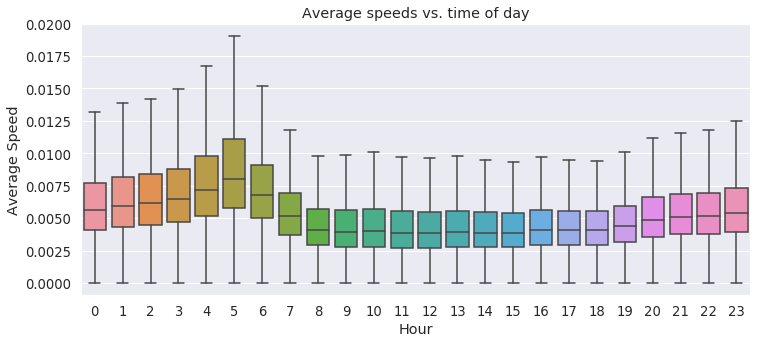

In [34]:
# Calculate the manhattan distance and speed
manhattan = manhattan_distance(data['pickup_latitude'],data['dropoff_latitude'],data['pickup_longitude'],data['dropoff_longitude'])
manhattan_speed = manhattan / data['trip_duration']

# Plot speed against the time of day
sns.set(font_scale=1.2)
plt.figure(figsize=(12, 5))
sns.boxplot(data['hr'], manhattan_speed, showfliers=False)
plt.title('Average speeds vs. time of day')
plt.ylabel('Average Speed')
plt.xlabel('Hour')
plt.show()

/opt/conda/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6571: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


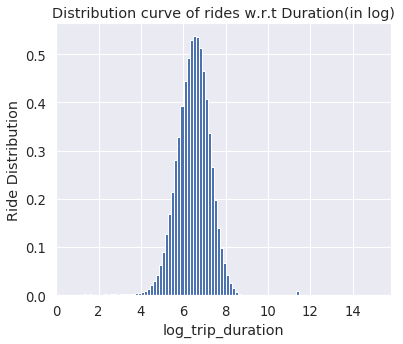

In [35]:
# distributionof trip duration
sns.set(font_scale=1.2)
plt.figure(figsize=(6, 5))
plt.hist(sorted(data['log_trip_duration']), bins=100, normed=True)
plt.title('Distribution curve of rides w.r.t Duration(in log)')
plt.ylabel('Ride Distribution')
plt.xlabel('log_trip_duration')
plt.show()

In [36]:
#Workhours time
tempdata = data
tempdata = pd.concat([tempdata, time_data], axis=1)

Text(0.5,1,'log_trip_duration vs hr of the day')

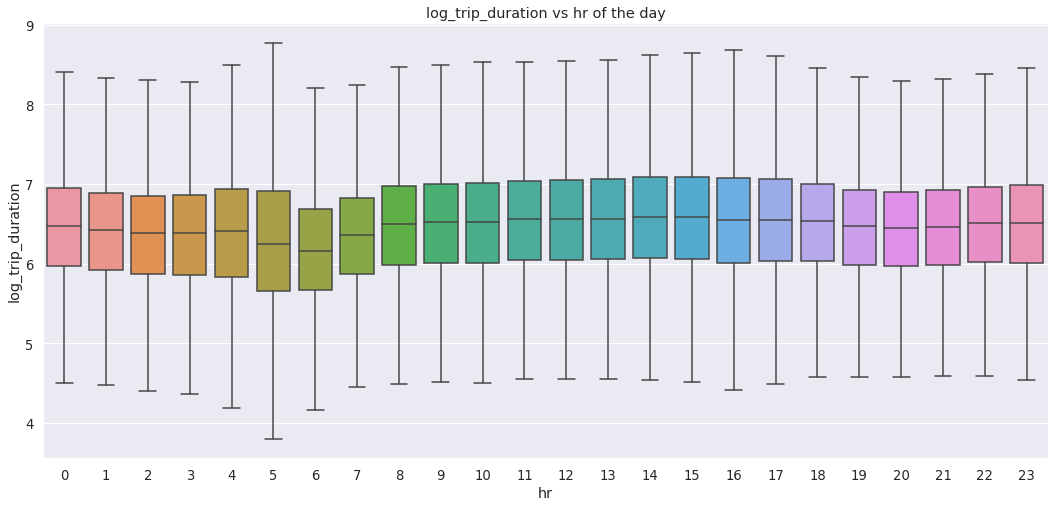

In [37]:
#fig = plt.figure(figsize = (18,8))
sns.set(font_scale=1.2)
plt.figure(figsize=(18, 8))
sns.boxplot(x = "hr", y="log_trip_duration", data = data, showfliers = False)
plt.title("log_trip_duration vs hr of the day")

Text(0.5,1,'Comparision of log_trip_duration vs month for rest_day and working day')

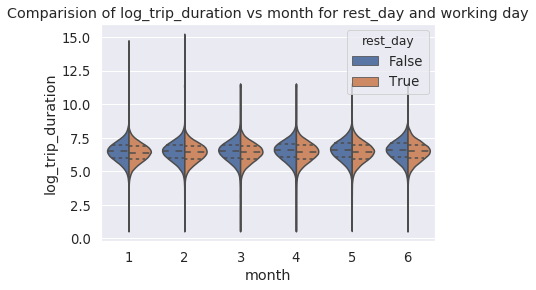

In [38]:
#month vs trip_duration
sns.violinplot(x = "month", y="log_trip_duration", hue = "rest_day", data=tempdata, split=True, inner = "quart")
plt.title("Comparision of log_trip_duration vs month for rest_day and working day")

## LETS MODEL AWAY

In [40]:
#THE XGBOOST
# dropping off the target variables
mydf = data[['vendor_id','passenger_count','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','store_and_fwd_flag']]
testdf = test[['vendor_id','passenger_count','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','store_and_fwd_flag']]

In [41]:
#converting kmeans data into one hot encoding for XGBOOSTING
kmeans_data = pd.get_dummies(kmean_data.pickup_dropoff_loc, prefix='loc', prefix_sep = '_')
kmeans_test = pd.get_dummies(kmean_test.pickup_dropoff_loc, prefix='loc', prefix_sep = '_')

In [42]:
#merging the entire feature space
mydf  = pd.concat([mydf  ,time_data,weather_data,osrm_data,Other_dist_data,kmeans_data],axis=1)
testdf= pd.concat([testdf,time_test,weather_test,osrm_test,Other_dist_test,kmeans_test],axis=1)

In [43]:
# checking if test and training sets are similar
print(np.all(mydf.keys()==testdf.keys()))

True


In [44]:

X = mydf
z = data['log_trip_duration'].values


In [45]:
# verifying if the keys are similar
print(X.keys() == testdf.keys())

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


In [46]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [47]:
# 80-20 split for training and validation
Xtrain, Xval, Ztrain, Zval = train_test_split(X, z, test_size=0.2, random_state =42)
#50-50 validation set split
Xcv,Xv,Zcv,Zv = train_test_split(Xval, Zval, test_size=0.5, random_state=1)
#DMatrix conversion for xgb
data_tr  = xgb.DMatrix(Xtrain, label=Ztrain)
data_cv  = xgb.DMatrix(Xcv   , label=Zcv)
evallist = [(data_tr, 'train'), (data_cv, 'valid')]


### TRAINING AND HYPERPARAMETER TUNING

In [48]:
parms = {'max_depth':15, #maximum depth of a tree 8 12
         'objective':'reg:linear',
         'eta'      :0.05, #0.3
         'subsample':0.9,#SGD will use this percentage of data 0.8 0.99
         'lambda '  :3, #L2 regularization term,>1 more conservative 4 
         'colsample_bytree ':0.6, #0.9
         'colsample_bylevel':0.7, #1 0.7
         'min_child_weight': 0.5, #10 0.5
         #'nthread'  :3 ... default is max cores
         'eval_metric':'rmse'}  #number of cpu core to use
# running for 2k iterations 
model = xgb.train(parms, data_tr, num_boost_round=2000, evals = evallist,
                  early_stopping_rounds=50, maximize=False, 
                  verbose_eval=100)


# The optimization function replacing GridSearchCV implemented with the help of the kaggle kernel of beluga
'''                  

Flag = True
xgb_pars = []
for min_child_weight in [0.5, 1, 2, 4]:
    for ETA in [0.05, 0.1, 0.15]:
        for colsample_bytree in [0.5,0.6,0.7,0.8,0.9]:
            for max_depth in [6, 8, 10, 12, 15]:
                for subsample in [0.5, 0.6, 0.7, 0.8, 0.9]:
                    for lambda in [0.5, 1., 1.5,  2., 3.,4.]:
                        xgb_pars.append({'min_child_weight': min_child_weight, 'eta': ETA,
                                         'colsample_bytree': colsample_bytree, 'max_depth': max_depth,
                                         'subsample': subsample, 'lambda': lambda, 
                                         'eval_metric': 'rmse','silent': 1, 'objective': 'reg:linear'})

while Flag:
    xgb_par = np.random.choice(xgb_pars, 1)[0]
    print(xgb_par)
    model = xgb.train(xgb_par, data_tr, 2000, evallist, early_stopping_rounds=50,maximize=False, verbose_eval=100)
    print('Modeling RMSLE %.6f' % model.best_score)
'''
#the final score achieved by the set parameters and the iterations required for achieveing it (early stopping) 

print('score = %1.5f, n_boost_round =%d.'%(model.best_score,model.best_iteration))

[04:48:28] src/tree/updater_prune.cc:74: tree pruning end, 1 roots, 1414 extra nodes, 0 pruned nodes, max_depth=15
[0]	train-rmse:5.72016	valid-rmse:5.72078
Multiple eval metrics have been passed: 'valid-rmse' will be used for early stopping.

Will train until valid-rmse hasn't improved in 50 rounds.
[04:48:34] src/tree/updater_prune.cc:74: tree pruning end, 1 roots, 1558 extra nodes, 0 pruned nodes, max_depth=15
[04:48:41] src/tree/updater_prune.cc:74: tree pruning end, 1 roots, 1702 extra nodes, 0 pruned nodes, max_depth=15
[04:48:47] src/tree/updater_prune.cc:74: tree pruning end, 1 roots, 1790 extra nodes, 0 pruned nodes, max_depth=15
[04:48:53] src/tree/updater_prune.cc:74: tree pruning end, 1 roots, 1734 extra nodes, 0 pruned nodes, max_depth=15
[04:48:59] src/tree/updater_prune.cc:74: tree pruning end, 1 roots, 2080 extra nodes, 0 pruned nodes, max_depth=15
[04:49:05] src/tree/updater_prune.cc:74: tree pruning end, 1 roots, 2160 extra nodes, 0 pruned nodes, max_depth=15
[04:49:1

## FEATURE IMPORTANCE

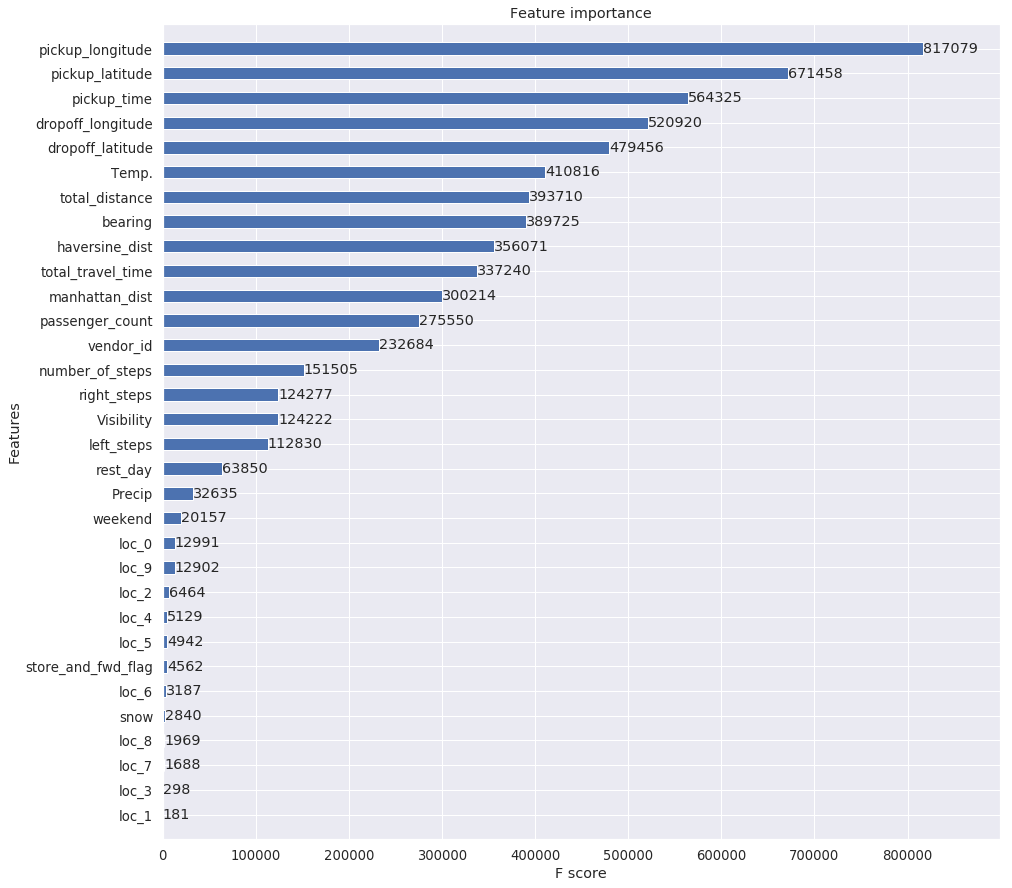

In [49]:
# Feature imporatnce graph using the xgb.plot_importance
fig =  plt.figure(figsize = (15,15))
axes = fig.add_subplot(111)
xgb.plot_importance(model,ax = axes,height =0.5)
plt.show();plt.close()

In [50]:
# prediction using the model from the test data
data_test = xgb.DMatrix(testdf)
ztest = model.predict(data_test)


In [51]:

ytest = np.exp(ztest)-1
print(ytest[:10])

[ 719.30396  553.2075   378.4586  1092.1722   376.93182  855.0072
 1516.372    850.14215 2494.3054   483.00076]


In [52]:
#creating submission for kaggle
submission = pd.DataFrame({'id': test.id, 'trip_duration': ytest})
submission.to_csv('submission.csv', index=False)

### MODEL EVALUATION

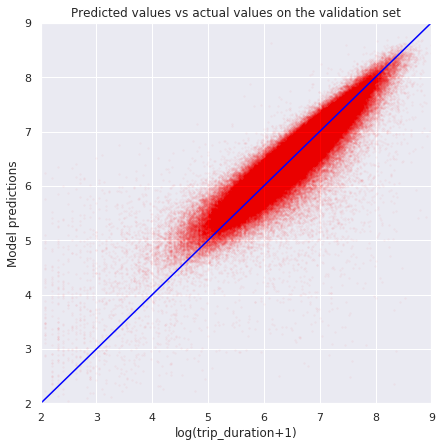

In [53]:
# model evaluation predicted vs actual values on validation set
pred_val = model.predict(xgb.DMatrix(Xval))

sns.set(font_scale=1)
plt.figure(figsize=(7, 7))
plt.scatter(Zval, pred_val, s=3, color='red', alpha=0.025)
plt.plot([1,9],[1,9], color='blue')
plt.title('Predicted values vs actual values on the validation set')
plt.xlabel('log(trip_duration+1)')
plt.ylabel('Model predictions')
axes = plt.gca()
axes.set_xlim([2, 9])
axes.set_ylim([2, 9])
plt.show()
plt.show()